# EDA -- S&P 500 Stock Data

Exploratory analysis before building the autoencoder and PCA models.

All data loading and plotting is delegated to the `src` package so the
EDA and the experiments share the exact same inputs.

## 1. Setup & Data Loading

In [3]:
from src.plotting import setup_style, PLOTS_DIR
from src import data as data_mod
from src import plotting as plotting_mod

setup_style()

# Load the wide close-price matrix and the (complete-only) log-return matrix.
prices      = data_mod.load_prices()
log_returns = data_mod.load_log_returns(complete_only=True)

print(f'Price matrix shape: {prices.shape}  (days x stocks)')
print(f'Date range: {prices.index[0].date()} -> {prices.index[-1].date()}')
print(f'Log-return matrix (complete stocks only): {log_returns.shape}')
prices.head(10)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\masha\\Data Science\\2 semester\\EFFE\\PCA-AE-comparison-EFFE\\data\\individual_stocks_5yr\\individual_stocks_5yr'

In [2]:
# Top-20 stocks with the most missing close prices.
prices.isna().sum().sort_values(ascending=False).head(20)

APTV    1215
DWDP    1150
BHF     1116
BHGE    1107
DXC     1044
HLT      983
EVHC     962
FTV      855
UA       795
WLTW     731
CSRA     698
HPE      678
HPQ      678
PYPL     604
KHC      604
WRK      597
QRVO     478
CFG      409
SYF      371
INFO     342
dtype: int64

In [3]:
import numpy as np

log_returns_with_NaNs = np.log(prices / prices.shift(1)).iloc[1:]
missing_pct = log_returns_with_NaNs.isna().mean() * 100
print(f'Stocks with any missing returns: {(missing_pct > 0).sum()}')
print(f'Stocks with >5% missing:         {(missing_pct > 5).sum()}')
print(f'Stocks kept (complete data):     {log_returns.shape[1]}')

Stocks with any missing returns: 35
Stocks with >5% missing:         28
Stocks kept (complete data):     470


## 2. Single-Stock Exploration

Four stocks from different sectors to show what the raw material looks like.

In [4]:
PICKS = {
    'AAPL': 'Technology',
    'AMZN': 'Consumer Discretionary',
    'BAC':  'Financials',
    'AEP':  'Utilities',
}

### 2a. Price vs. log-return over time
Raw prices drift upward and have no stable distribution -- log returns are the right input.

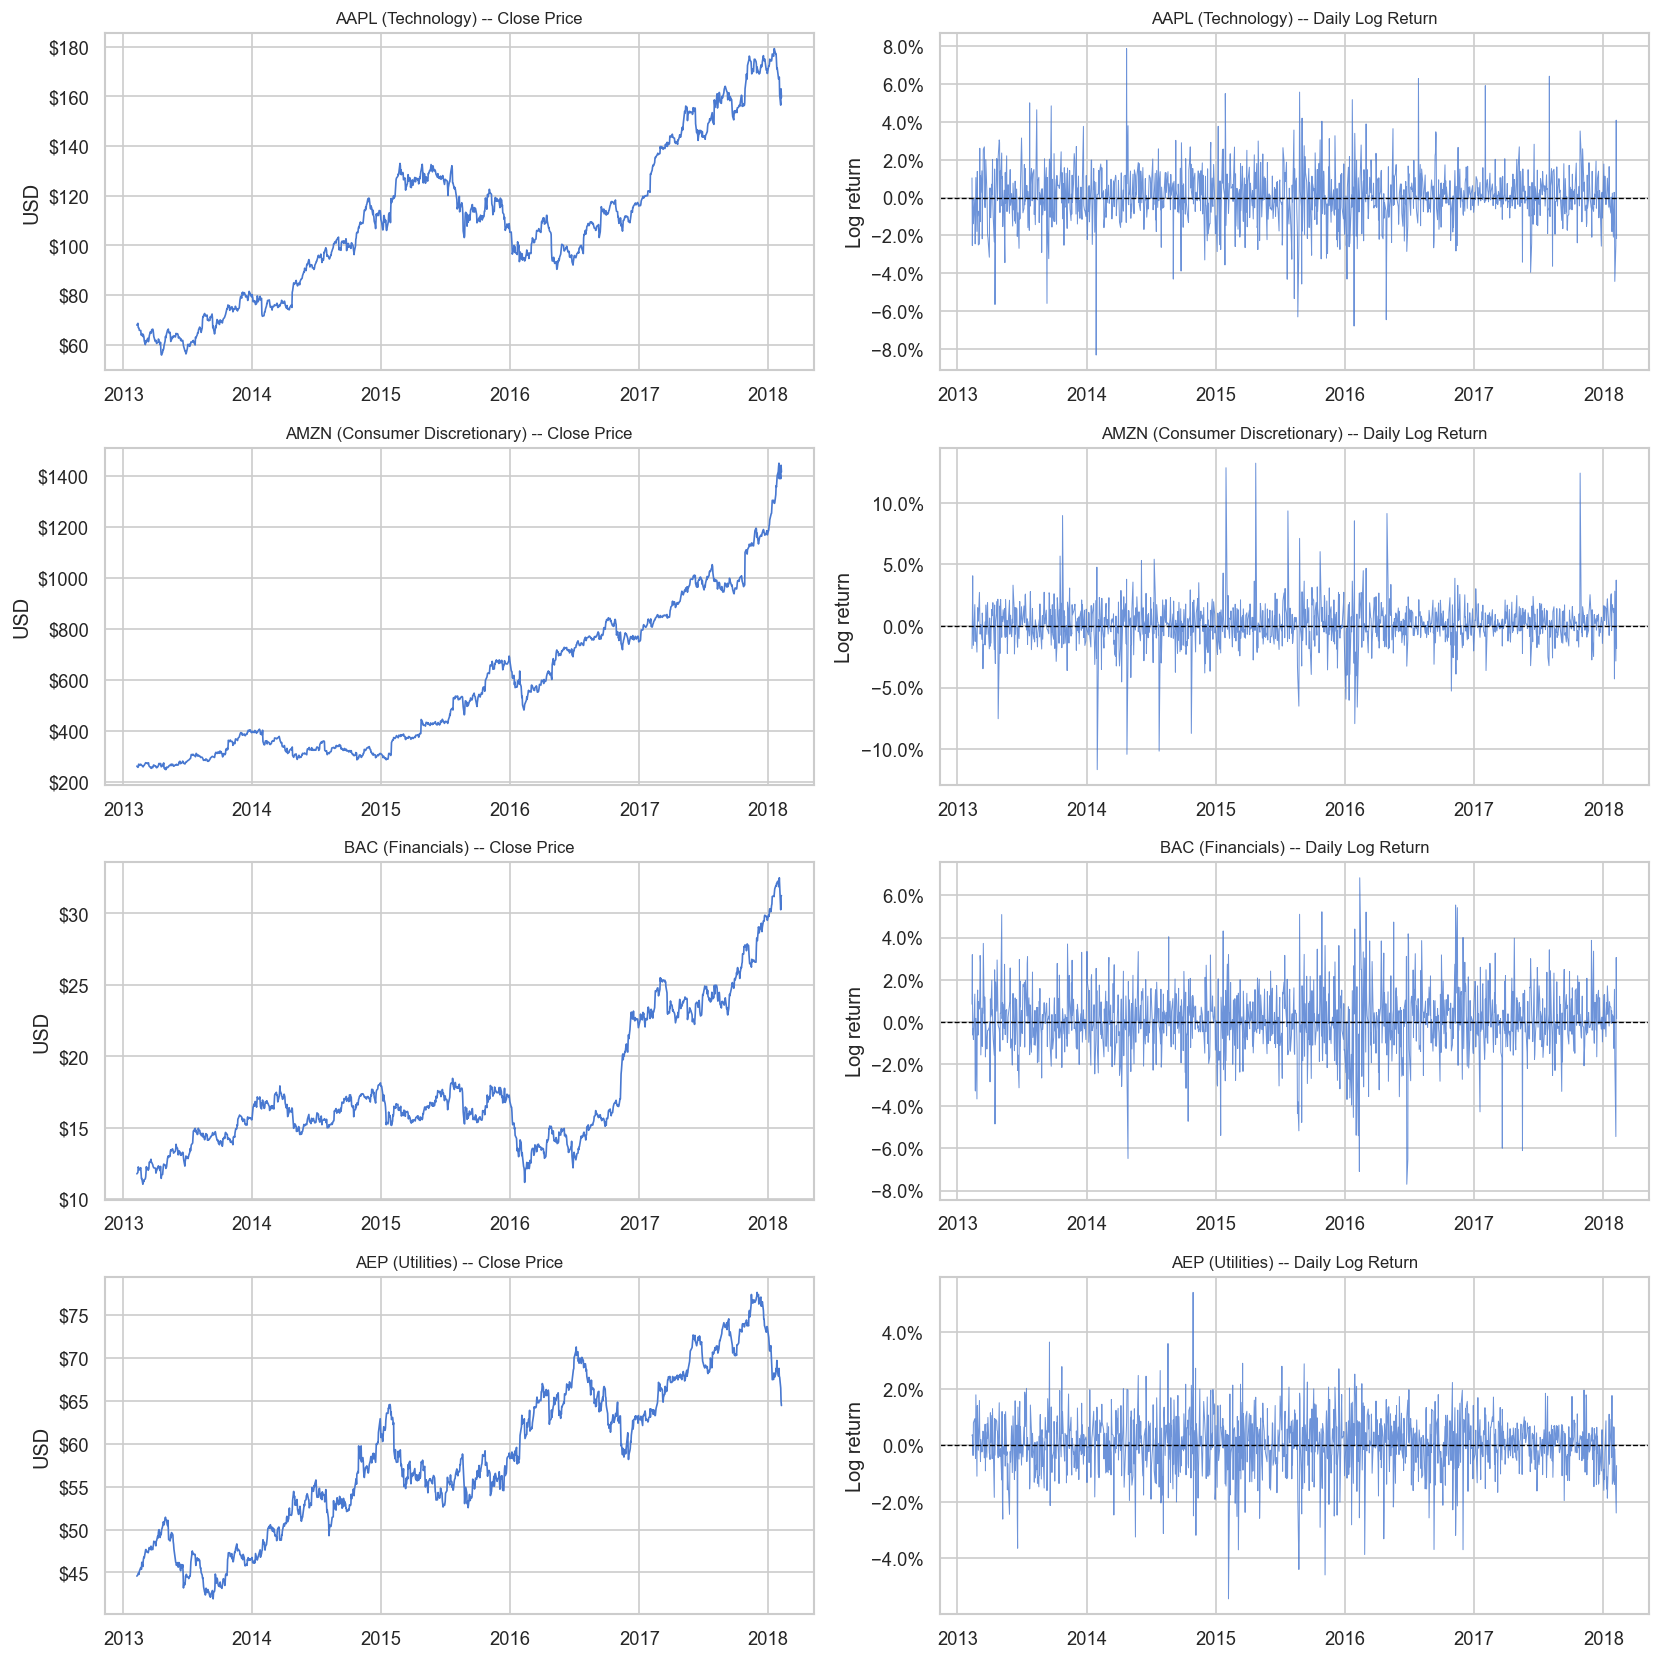

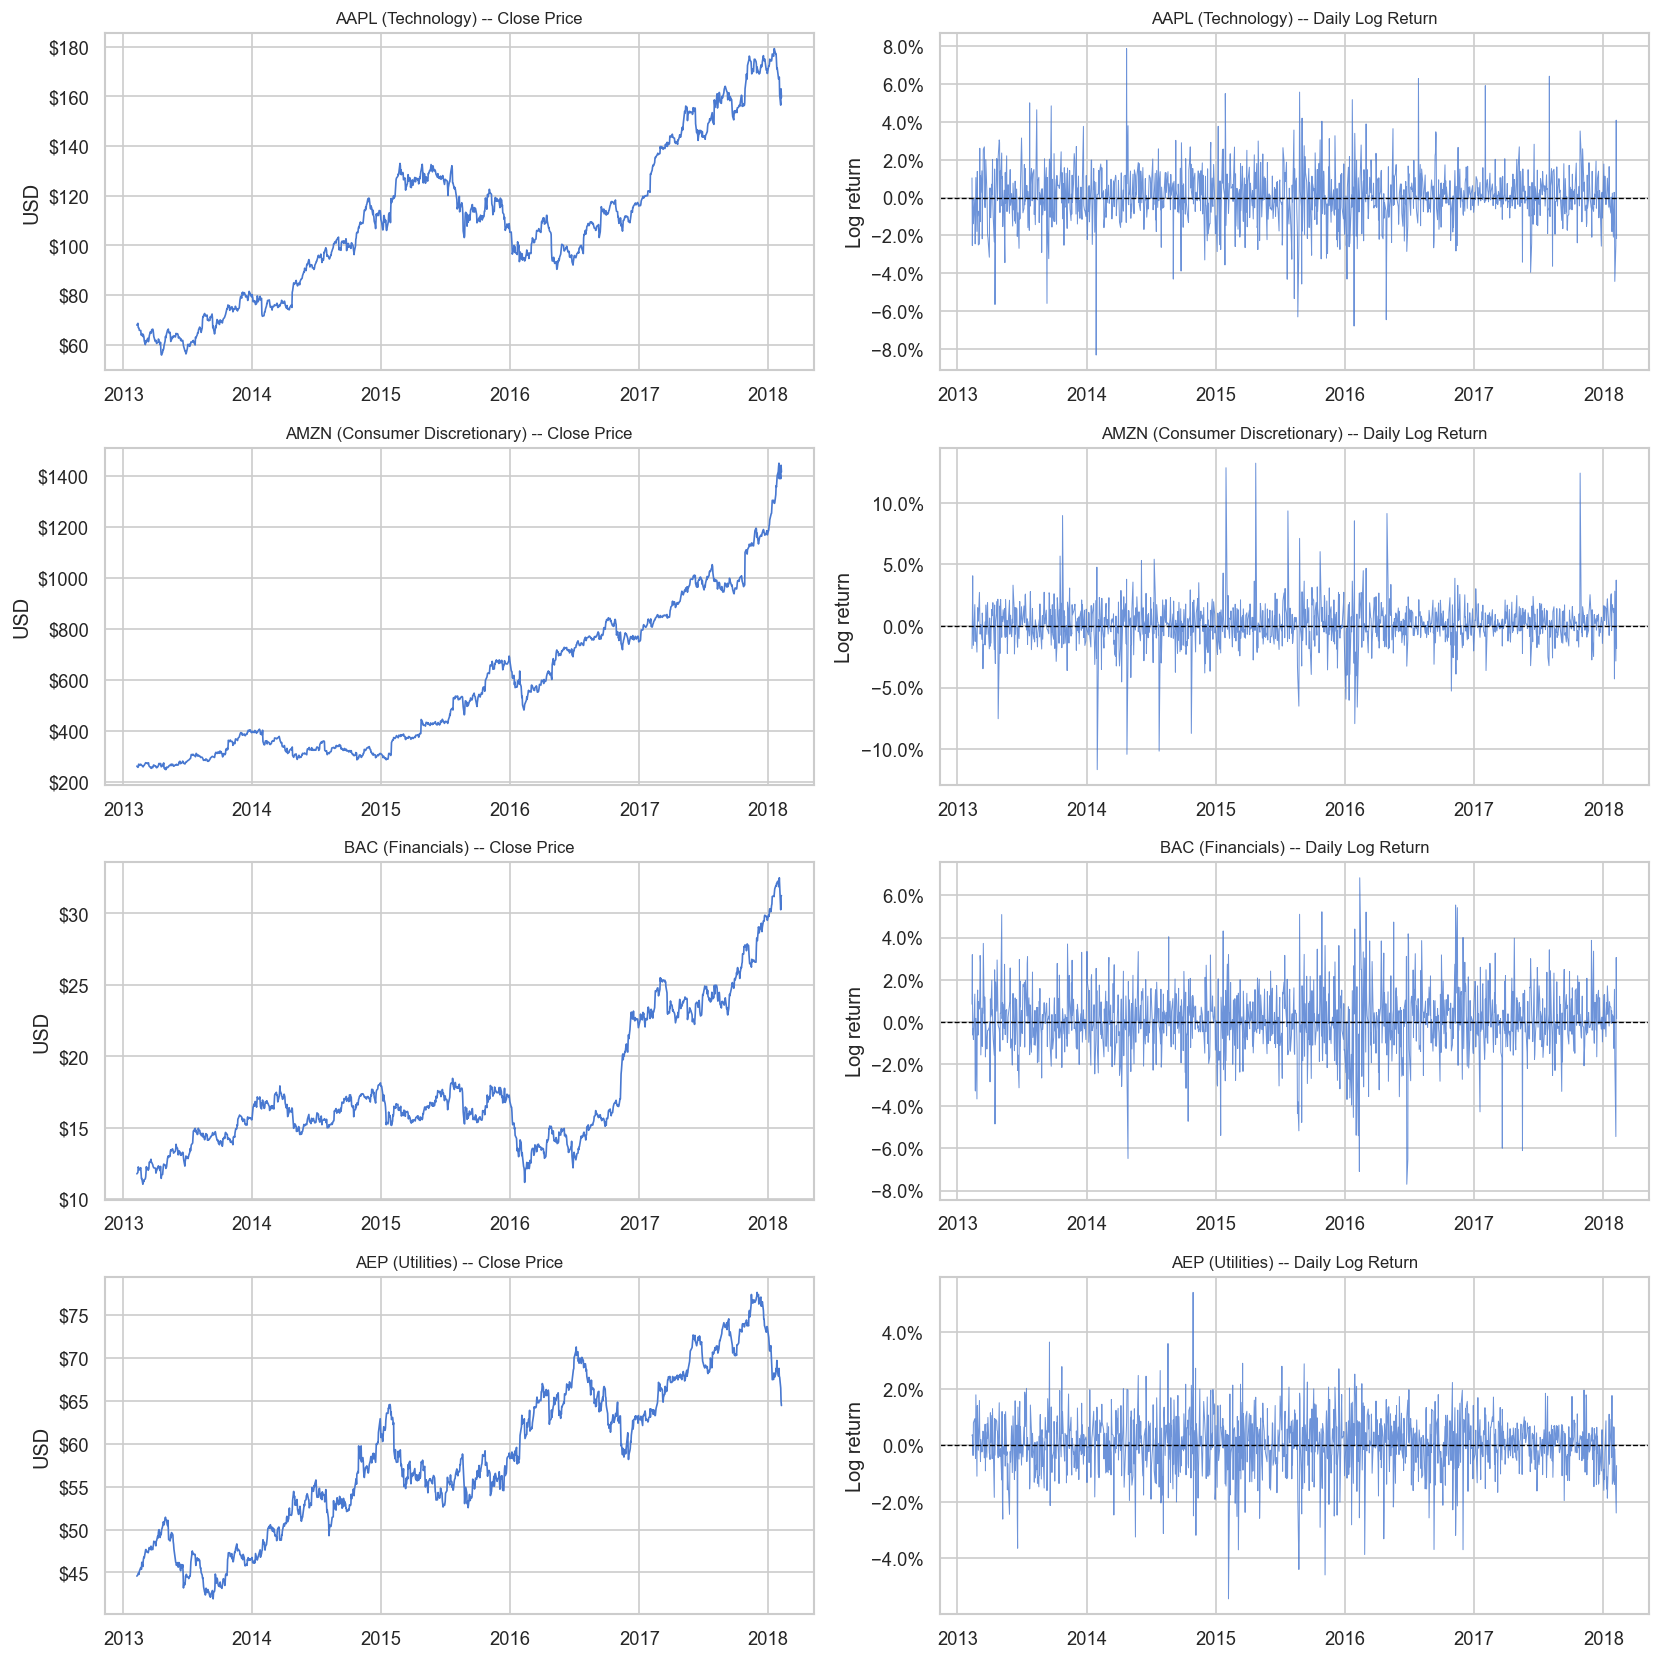

In [5]:
plotting_mod.plot_price_vs_returns(
    prices, log_returns, PICKS,
    save_path=PLOTS_DIR + 'plot_price_vs_returns.png',
)

### 2b. Return distribution per stock
Histogram + fitted normal curve. Real returns are fat-tailed (positive excess kurtosis).

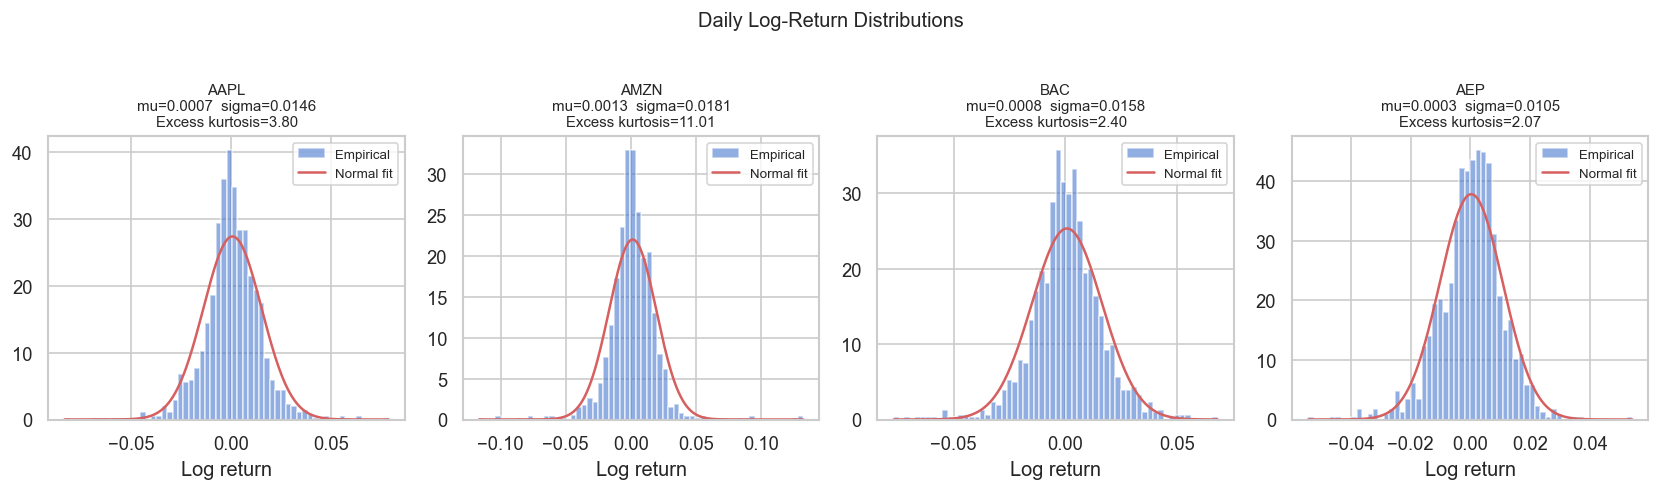

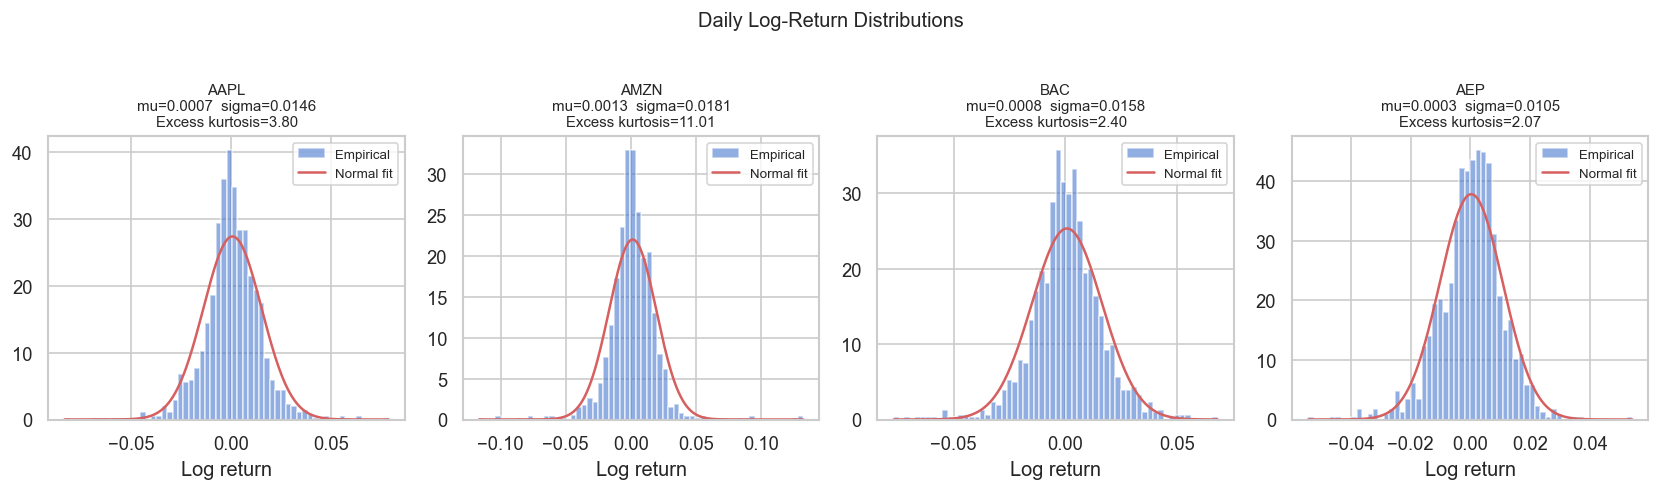

In [6]:
plotting_mod.plot_return_distributions(
    log_returns, PICKS,
    save_path=PLOTS_DIR + 'plot_return_distributions.png',
)

### 2c. Rolling 30-day annualised volatility
Volatility clusters over time -- calm periods and turbulent periods are visibly distinct.

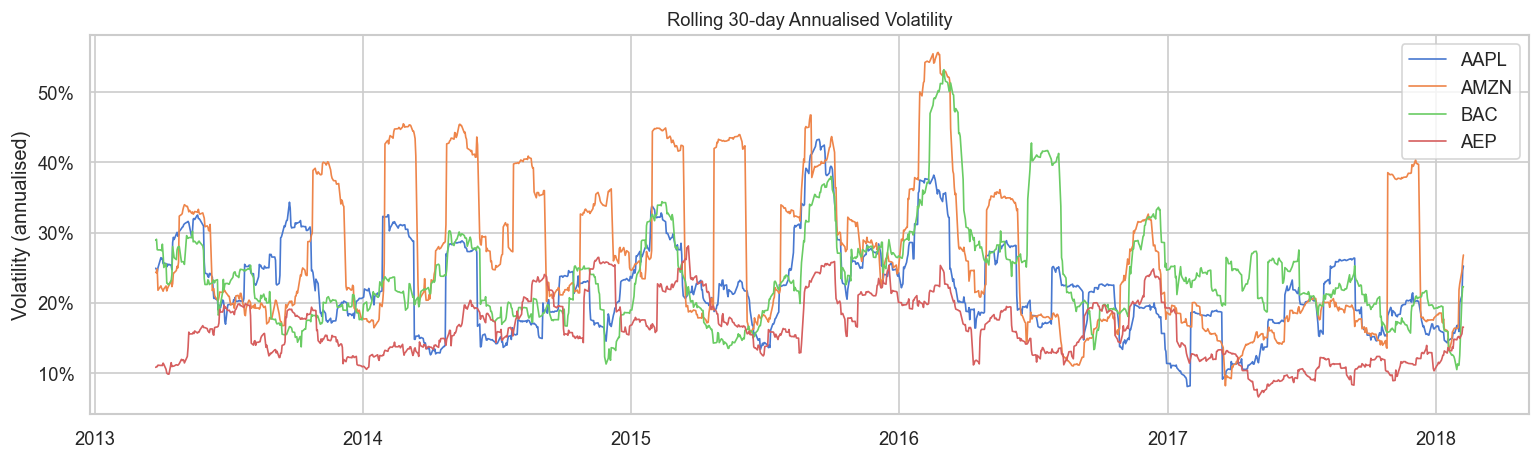

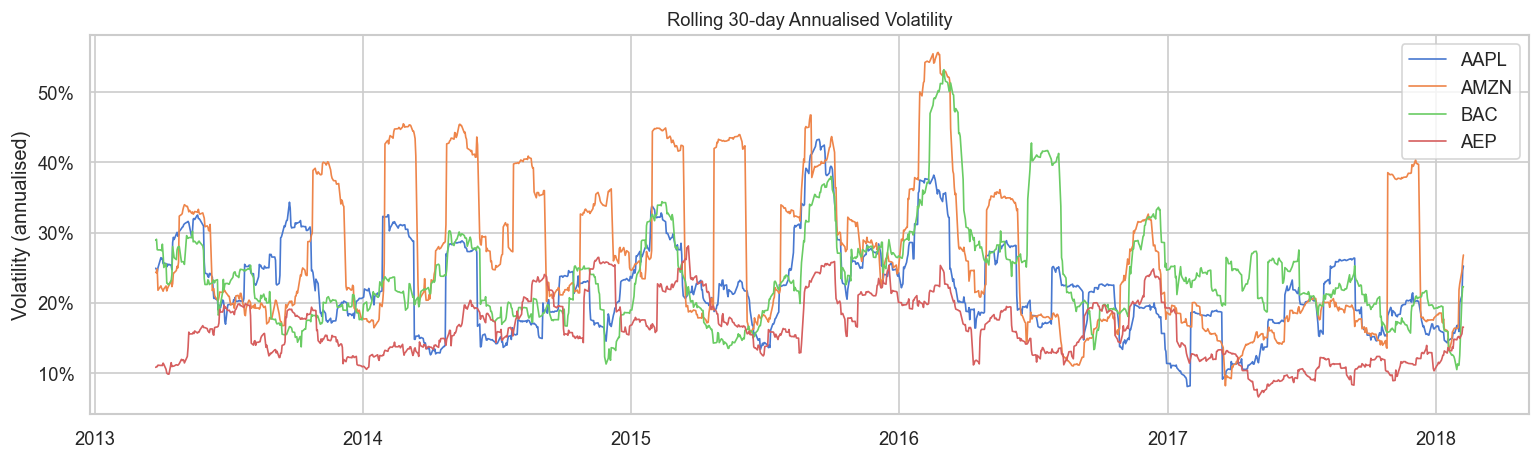

In [7]:
plotting_mod.plot_rolling_volatility(
    log_returns, PICKS, window=30,
    save_path=PLOTS_DIR + 'plot_rolling_volatility.png',
)

## 3. Cross-Stock Structure

Why dimensionality reduction makes sense: the 500+ tickers are strongly correlated.

### 3a. Distribution of pairwise correlations

mean: 0.283, median: 0.272, min: -0.123, max: 0.985


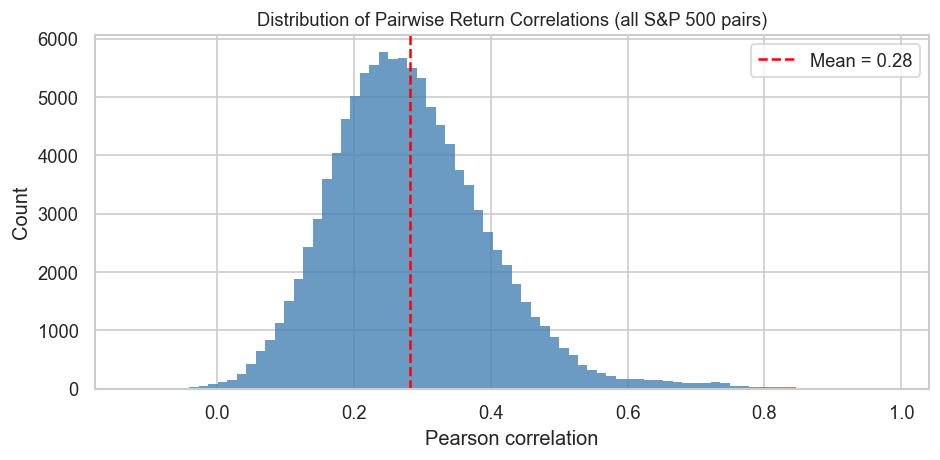

In [8]:
corr_matrix = log_returns.corr()
_, pairwise_corrs = plotting_mod.plot_pairwise_correlation_distribution(
    corr_matrix,
    save_path=PLOTS_DIR + 'plot_pairwise_correlations.png',
)
print(f'mean: {pairwise_corrs.mean():.3f}, median: {np.median(pairwise_corrs):.3f}, '
      f'min: {pairwise_corrs.min():.3f}, max: {pairwise_corrs.max():.3f}')

### 3b. Correlation heatmap -- 40 selected stocks
Plotting all ~505x505 is unreadable; we pick 10 stocks from 4 sectors to show the block structure.

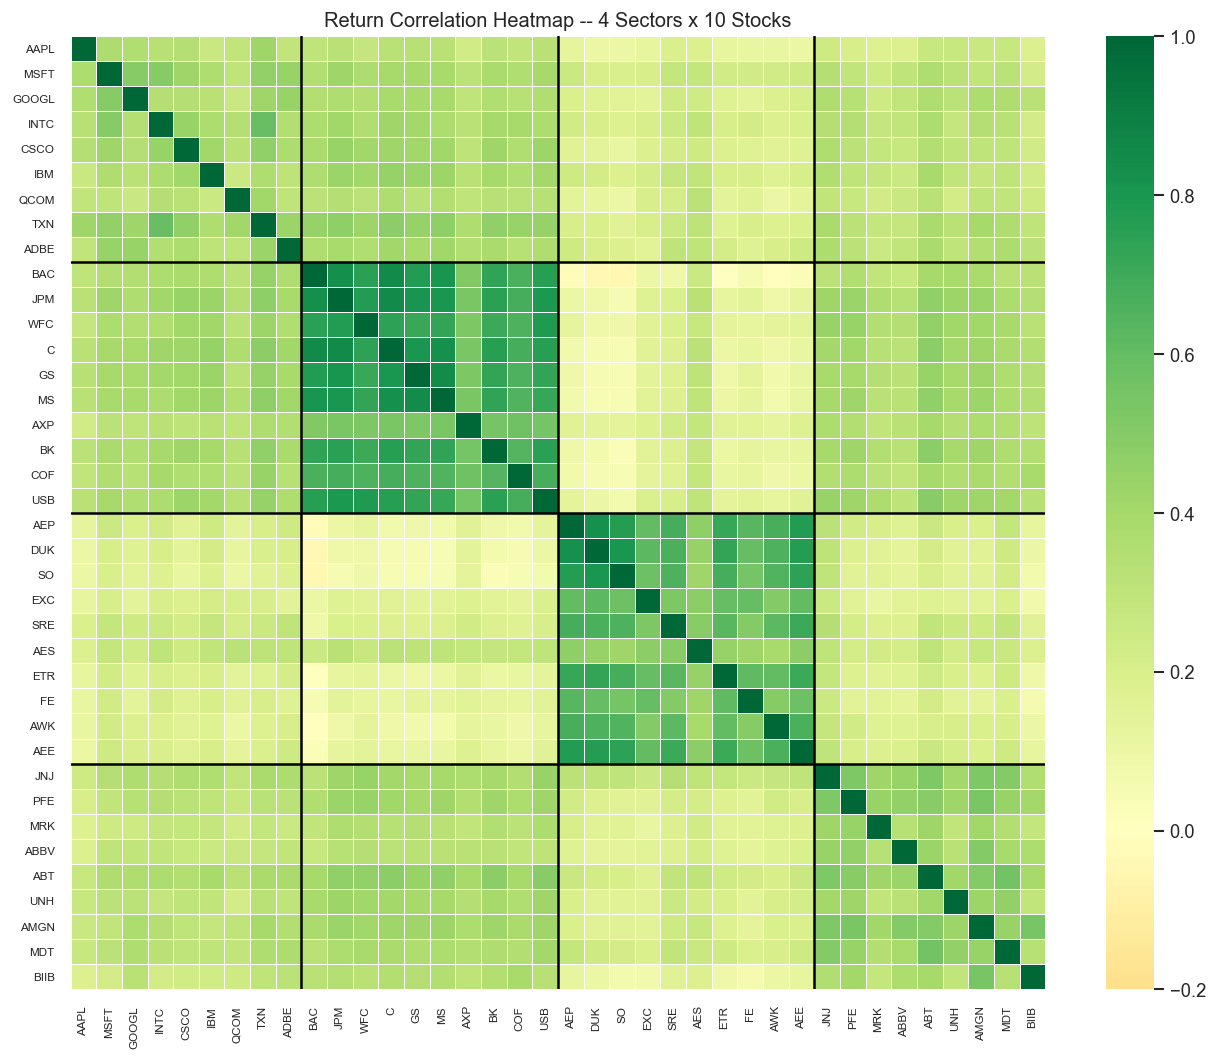

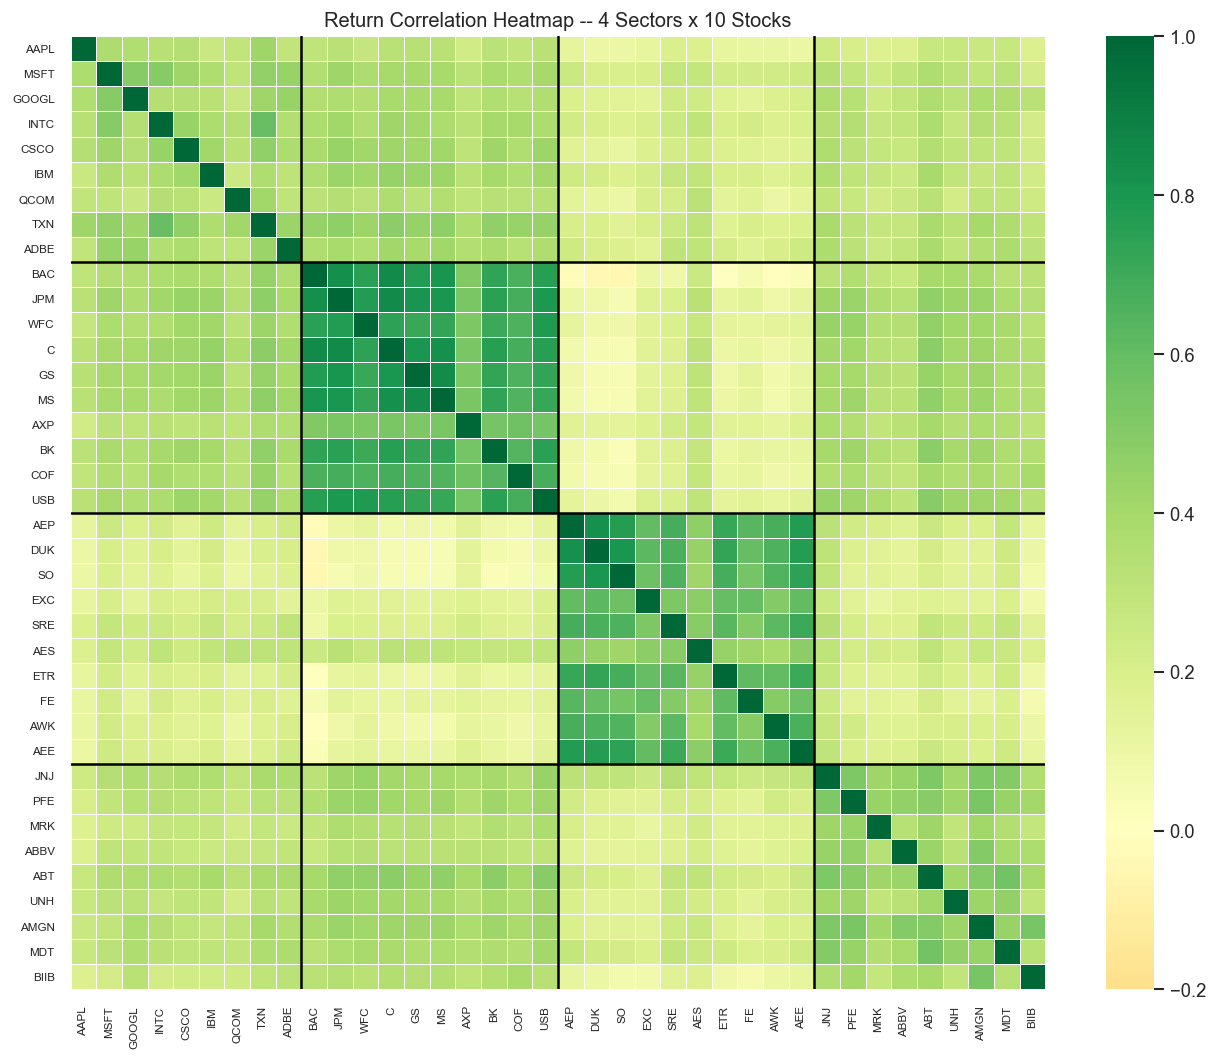

In [9]:
SECTOR_SAMPLES = {
    'Tech':       ['AAPL', 'MSFT', 'GOOGL', 'INTC', 'CSCO', 'ORCL', 'IBM', 'QCOM', 'TXN', 'ADBE'],
    'Financials': ['BAC', 'JPM', 'WFC', 'C', 'GS', 'MS', 'AXP', 'BK', 'COF', 'USB'],
    'Utilities':  ['AEP', 'DUK', 'SO', 'EXC', 'SRE', 'AES', 'ETR', 'FE', 'AWK', 'AEE'],
    'Healthcare': ['JNJ', 'PFE', 'MRK', 'ABBV', 'ABT', 'UNH', 'AMGN', 'BMY', 'MDT', 'BIIB'],
}

plotting_mod.plot_correlation_heatmap(
    log_returns, SECTOR_SAMPLES,
    save_path=PLOTS_DIR + 'plot_correlation_heatmap.png',
)

## 4. PCA Baseline -- Explained Variance

How many principal components are needed to capture most of the variance? This sets the target latent dimension for the autoencoder.

80% variance explained by 136 components  (compression ratio 3.5x)
90% variance explained by 225 components  (compression ratio 2.1x)
95% variance explained by 298 components  (compression ratio 1.6x)


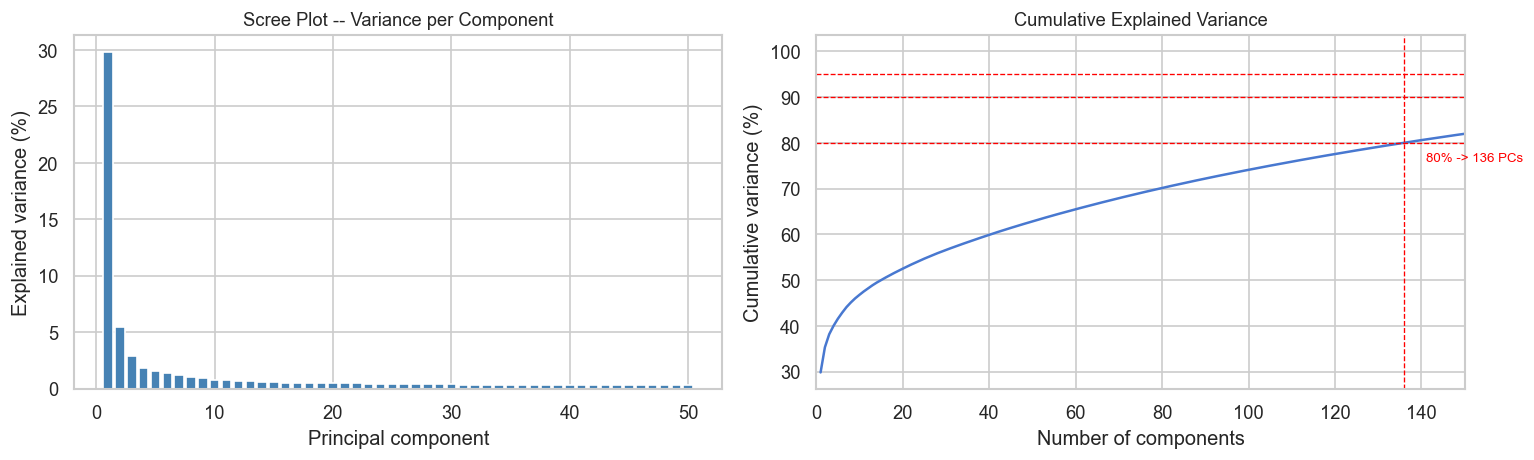

In [10]:
from sklearn.decomposition import PCA

X = log_returns.values
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

pca = PCA().fit(X_std)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plotting_mod.plot_pca_scree(
    explained, n_show=50, thresholds=(0.80, 0.90, 0.95),
    save_path=PLOTS_DIR + 'plot_pca_variance.png',
)

for t in (0.80, 0.90, 0.95):
    n = int(np.argmax(cumulative >= t) + 1)
    print(f'{int(t*100)}% variance explained by {n} components  '
          f'(compression ratio {log_returns.shape[1]/n:.1f}x)')

### 4b. First two principal components
Projecting all days onto PC1 and PC2 -- useful to see macro-level structure (market-wide shocks).

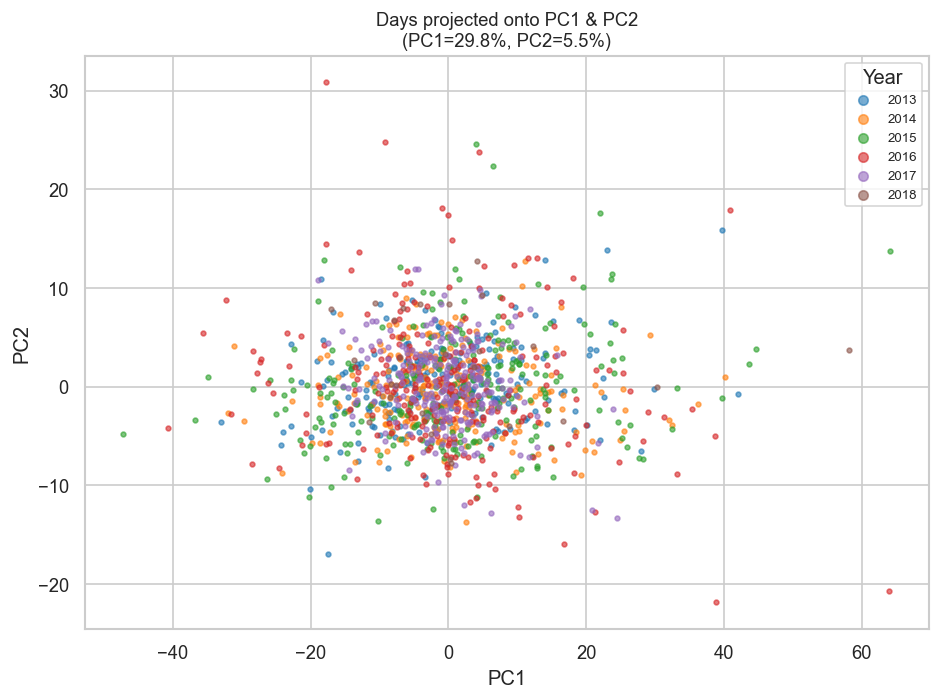

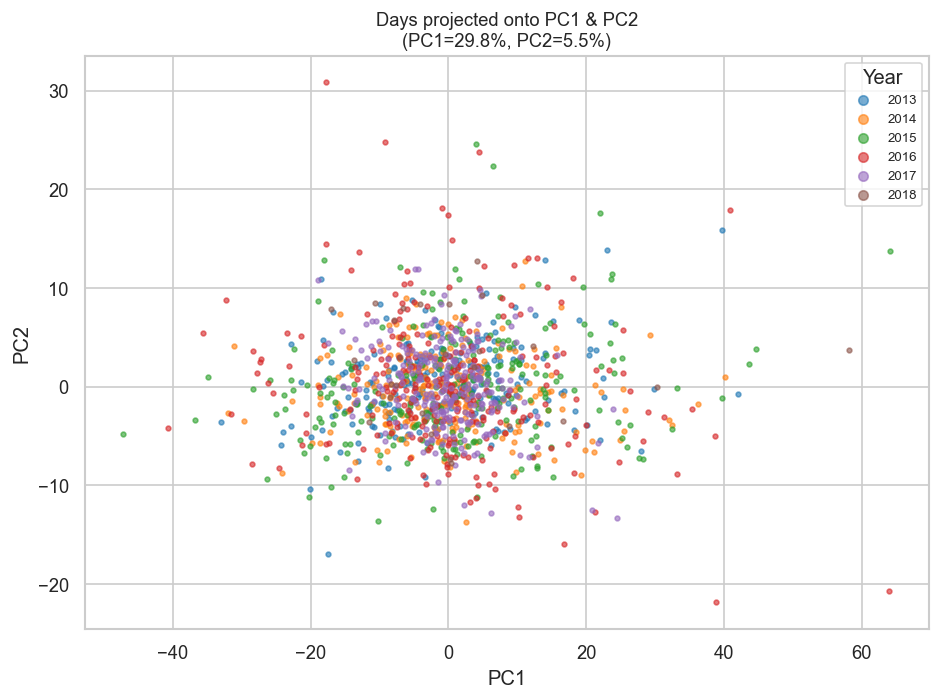

In [11]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X_std)

plotting_mod.plot_pca_2d(
    coords, log_returns.index.year, pca2.explained_variance_ratio_,
    save_path=PLOTS_DIR + 'plot_pca_2d.png',
)

## 5. Summary Statistics

In [12]:
import pandas as pd

summary = pd.DataFrame({
    'mean':     log_returns.mean(),
    'std':      log_returns.std(),
    'skewness': log_returns.skew(),
    'kurtosis': log_returns.kurtosis(),  # excess kurtosis
    'min':      log_returns.min(),
    'max':      log_returns.max(),
})
print('Cross-sectional distribution of per-stock statistics:')
summary.describe().round(4)

Cross-sectional distribution of per-stock statistics:


,mean,std,skewness,kurtosis,min,max
count,470.0000,470.0000,470.0000,470.0000,470.0000,470.0000
mean,0.0004,0.0154,-0.6314,18.6093,-0.1242,0.0988
std,0.0004,0.0047,2.3053,67.1397,0.0974,0.0626
min,-0.0015,0.0084,-27.9335,0.9550,-0.9840,0.0286
25%,0.0002,0.0122,-0.6919,3.4227,-0.1400,0.0601
50%,0.0004,0.0144,-0.3314,5.8596,-0.0993,0.0820
75%,0.0007,0.0176,-0.0285,13.1631,-0.0722,0.1176
max,0.0023,0.0416,6.4164,914.5468,-0.0393,0.6979


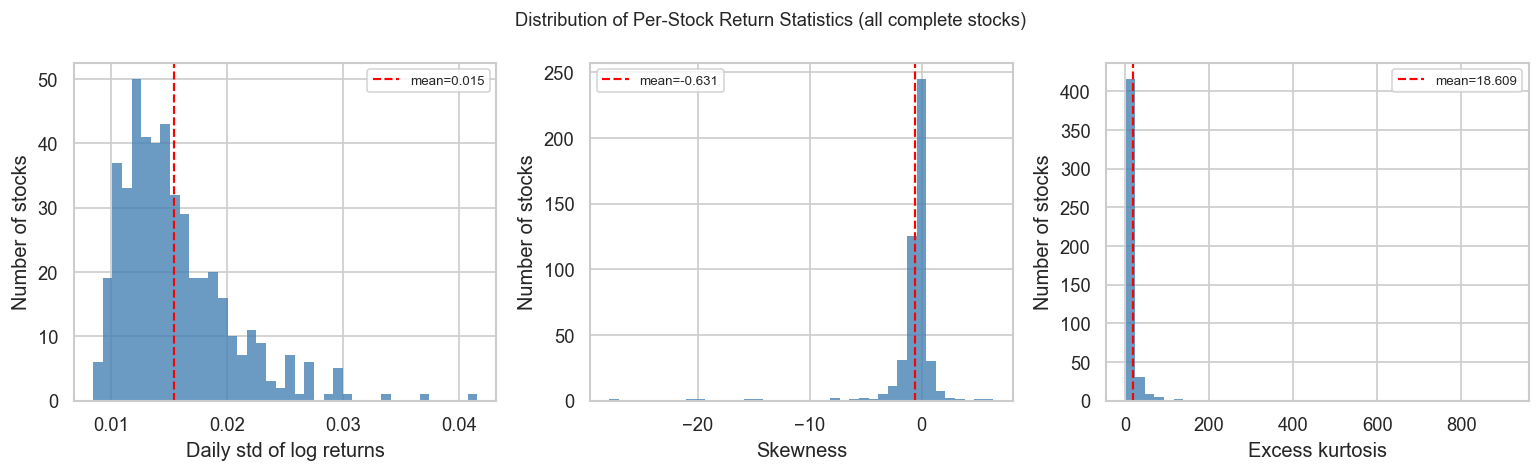

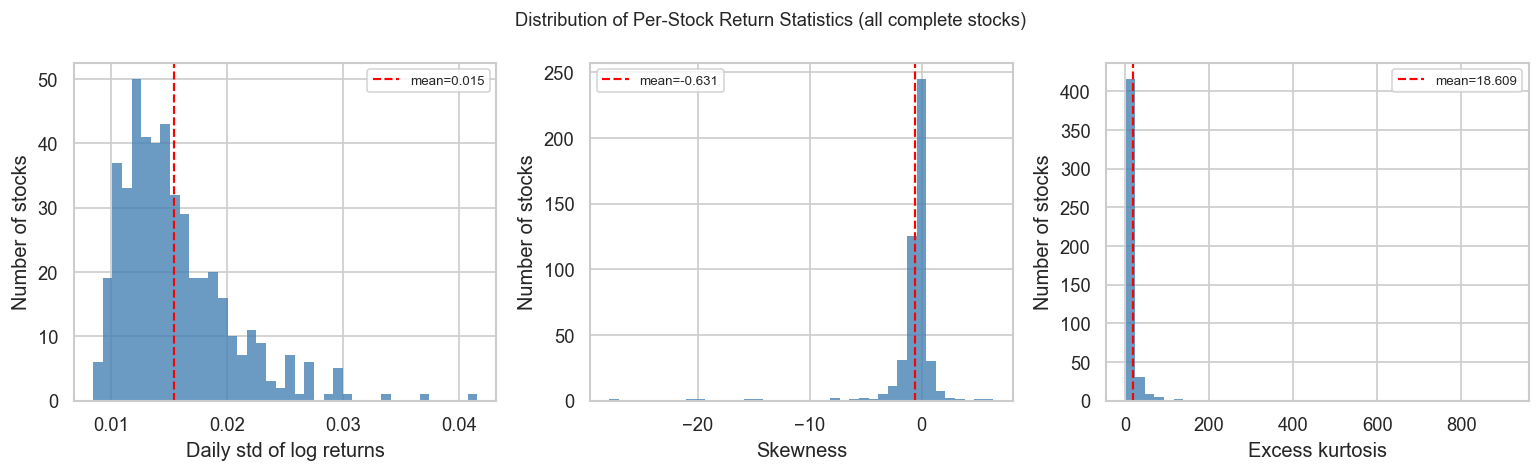

In [13]:
plotting_mod.plot_summary_stats(
    summary,
    save_path=PLOTS_DIR + 'plot_summary_stats.png',
)